# Two consecutive Recs: non-Markovianity of logical errors

A **Rec** = unitary encoder · wait · EC gadget · unitary decoder. Here we run **two consecutive Recs** under

- depolarizing noise (rate `p`) on the data during each Rec's wait — modelled by 2 independent depolarizing-`p` Paulis XOR'd into one fault path (matching `monte_carlo_new` in `exRec_logicalerror_distribution.ipynb`),
- bit-flip noise (rate `q`) on each EC gadget's syndrome readout, independent across the two Recs.

We track `(L1, s1, L2, s2)` — logical error and output syndrome of each Rec — and look at the joint distribution. If the system were Markovian, `L2` would be independent of `L1` once we condition on `s1`; deviations from independence are a fingerprint of non-Markovianity from the residual error carried between Recs.

Headline diagnostics:

1. **Conditional 4×4 matrix** `P(L2 | L1)` — rows = first Rec's logical error, cols = second's.
2. **Difference from product** `P(L1, L2) − P(L1) P(L2)` — zero iff Markovian-independent at the logical level.
3. **Mutual information** `I(L1 ; L2)` (in bits) — scalar measure of how much knowing `L1` reduces uncertainty about `L2`.
4. Same three diagnostics for `(s1, s2)`.
5. Sweeps of the mutual informations over `q` (fixed `p`) and over `p` (fixed `q`).

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

from pauli_utils import LOGICAL_NAMES, pauli_str, str_to_pauli
from StabilizerCode import StabilizerCode

## 1. Code definition

[[5,1,3]] perfect code, same as in `exRec_logicalerror_distribution.ipynb`.

In [12]:
code_513 = StabilizerCode(
    n=5,
    generators=[
        (np.array([1,0,0,1,0]), np.array([0,1,1,0,0])),  # XZZXI
        (np.array([0,1,0,0,1]), np.array([0,0,1,1,0])),  # IXZZX
        (np.array([1,0,1,0,0]), np.array([0,0,0,1,1])),  # XIXZZ
        (np.array([0,1,0,1,0]), np.array([1,0,0,0,1])),  # ZXIXZ
    ],
    logical_x=(np.array([1,1,1,1,1]), np.array([0,0,0,0,0])),
    logical_z=(np.array([0,0,0,0,0]), np.array([1,1,1,1,1])),
    name='[[5,1,3]]',
)
code = code_513
print(code)

StabilizerCode('[[5,1,3]]', n=5, r=4, n_syndromes=16)


## 2. Two-Rec simulation core

`run_one_rec` propagates a residual data Pauli `(xE, zE)` through a single Rec — wait fault (2 depolarizing-`p` Paulis XOR'd) → noisy syndrome readout (bit-flip rate `q`) → correction. Returns the post-Rec residual state, the logical class `L`, and the output syndrome `s_out`.

`simulate_two_recs` chains two Recs by carrying `(xE, zE)` through. The second Rec's input syndrome is implicit in the carried state — no need to reset it; the residual L1 from the first Rec is already baked into `(xE, zE)`.

`monte_carlo_two_recs` repeats and accumulates joint counts.

In [13]:
def sample_depolarizing_pauli(n, p, rng):
    """One n-qubit Pauli under independent depolarizing(p)."""
    xv = np.zeros(n, dtype=int)
    zv = np.zeros(n, dtype=int)
    r = rng.random(n)
    is_X = r < p / 3
    is_Y = (r >= p / 3) & (r < 2 * p / 3)
    is_Z = (r >= 2 * p / 3) & (r < p)
    xv[is_X | is_Y] = 1
    zv[is_Y | is_Z] = 1
    return xv, zv


def sample_syndrome_error_int(r, q, rng):
    """Syndrome bit-flip noise as an integer (each of r bits flips with prob q)."""
    bits = (rng.random(r) < q).astype(int)
    s = 0
    for i in range(r):
        s = (s << 1) | int(bits[i])
    return s


def run_one_rec(code, xE, zE, p, q, rng):
    """
    One Rec applied to incoming residual data Pauli (xE, zE).
    Returns updated (xE, zE), logical class L, output syndrome s_out.
    """
    # Wait fault: 2 depolarizing-p Paulis XOR'd
    x1, z1 = sample_depolarizing_pauli(code.n, p, rng)
    x2, z2 = sample_depolarizing_pauli(code.n, p, rng)
    xE = xE ^ x1 ^ x2
    zE = zE ^ z1 ^ z2

    # Noisy syndrome measurement
    s_mid = code.compute_syndrome(xE, zE)
    s_meas = s_mid ^ sample_syndrome_error_int(code.r, q, rng)

    # Apply decoder correction
    Cx, Cz = code.corrections[s_meas]
    xE = xE ^ Cx
    zE = zE ^ Cz

    # True post-correction syndrome and logical class
    s_out = code.compute_syndrome(xE, zE)
    Rx, Rz = code.corrections[s_out]
    L, _ = code.logical_class(xE ^ Rx, zE ^ Rz)
    return xE, zE, L, s_out


def simulate_two_recs(code, s_in_0, p, q, rng):
    """
    Two consecutive Recs. Initial data state = corrections[s_in_0].
    Returns (L1, s1, L2, s2).
    """
    Qx, Qz = code.corrections[s_in_0]
    xE, zE = Qx.copy(), Qz.copy()
    xE, zE, L1, s1 = run_one_rec(code, xE, zE, p, q, rng)
    xE, zE, L2, s2 = run_one_rec(code, xE, zE, p, q, rng)
    return L1, s1, L2, s2

In [14]:
def monte_carlo_two_recs(code, s_in_0, p, q, n_samples, seed=None):
    """
    Monte Carlo over n_samples runs of simulate_two_recs.

    Returns
    -------
    joint_L : (4, 4) int — joint_L[L1, L2]
    joint_s : (n_syn, n_syn) int — joint_s[s1, s2]
    """
    rng = np.random.default_rng(seed)
    n_syn = code.n_syndromes
    joint_L = np.zeros((4, 4), dtype=np.int64)
    joint_s = np.zeros((n_syn, n_syn), dtype=np.int64)
    for _ in range(n_samples):
        L1, s1, L2, s2 = simulate_two_recs(code, s_in_0, p, q, rng)
        joint_L[L1, L2] += 1
        joint_s[s1, s2] += 1
    return joint_L, joint_s


def conditional_from_joint(joint):
    """Row-stochastic P(B|A) from joint counts/probs (rows=A)."""
    J = joint.astype(float)
    row_sum = J.sum(axis=1, keepdims=True)
    P = np.divide(J, row_sum, out=np.zeros_like(J), where=row_sum > 0)
    return P


def mutual_information_bits(joint_counts):
    """I(A;B) in bits from a joint count matrix."""
    J = joint_counts.astype(float)
    total = J.sum()
    if total == 0:
        return 0.0
    P = J / total
    pa = P.sum(axis=1, keepdims=True)
    pb = P.sum(axis=0, keepdims=True)
    denom = pa * pb
    mask = (P > 0) & (denom > 0)
    return float(np.sum(P[mask] * np.log2(P[mask] / denom[mask])))

## 3. Parameters

In [15]:
# --- *** CHANGE INPUTS HERE *** ---
p_val     = 0.30        # depolarizing rate
q_val     = 0.10        # syndrome bit-flip rate
s_in_0    = 0           # initial input syndrome (clean encoded state -> 0)
N_SAMPLES = 200_000

print(f"code   = {code.name}")
print(f"p      = {p_val}")
print(f"q      = {q_val}")
print(f"s_in_0 = {s_in_0}")
print(f"N      = {N_SAMPLES}")

plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)
code_tag = code.name.replace('[', '').replace(']', '').replace(',', '-')

code   = [[5,1,3]]
p      = 0.3
q      = 0.1
s_in_0 = 0
N      = 200000


## 4. Run MC and compute joint / conditional / mutual info

Joint counts give us everything: marginals, conditionals, and a Markovian product reference.

In [16]:
joint_L, joint_s = monte_carlo_two_recs(code, s_in_0, p_val, q_val,
                                       n_samples=N_SAMPLES, seed=42)

# --- Logical-error analysis ---
P_joint_L     = joint_L / joint_L.sum()
P_L1          = P_joint_L.sum(axis=1)
P_L2          = P_joint_L.sum(axis=0)
P_L2_given_L1 = conditional_from_joint(joint_L)
P_product_L   = np.outer(P_L1, P_L2)
diff_L        = P_joint_L - P_product_L
I_LL          = mutual_information_bits(joint_L)

print("Marginals:")
print("  P(L1) =", dict(zip(LOGICAL_NAMES, P_L1.round(5))))
print("  P(L2) =", dict(zip(LOGICAL_NAMES, P_L2.round(5))))
print()
print("Conditional P(L2 | L1) (rows = L1, cols = L2):")
print("        " + "  ".join(f"{n:>8s}" for n in LOGICAL_NAMES))
for i, n in enumerate(LOGICAL_NAMES):
    print(f"  L1={n}  " + "  ".join(f"{P_L2_given_L1[i,j]:8.5f}"
                                    for j in range(4)))
print()
print(f"Mutual information  I(L1 ; L2) = {I_LL:.6f} bits")
print(f"max possible I(L1;L2) for 4-state vars = log2(4) = 2.0 bits")

Marginals:
  P(L1) = {'I': np.float64(0.30883), 'X': np.float64(0.23056), 'Y': np.float64(0.22933), 'Z': np.float64(0.23127)}
  P(L2) = {'I': np.float64(0.2544), 'X': np.float64(0.24945), 'Y': np.float64(0.24792), 'Z': np.float64(0.24823)}

Conditional P(L2 | L1) (rows = L1, cols = L2):
               I         X         Y         Z
  L1=I   0.29979   0.23566   0.23173   0.23283
  L1=X   0.23540   0.29393   0.23622   0.23445
  L1=Y   0.23460   0.23723   0.29235   0.23582
  L1=Z   0.23239   0.23561   0.23715   0.29485

Mutual information  I(L1 ; L2) = 0.007675 bits
max possible I(L1;L2) for 4-state vars = log2(4) = 2.0 bits


## 5. Logical-error heatmaps

Three panels: conditional `P(L2 | L1)`, joint `P(L1, L2)`, and the difference from the Markovian product `P(L1) P(L2)`.

Saved: plots/two_recs_logical_corr__5-1-3__sin0__p0.3__q0.1__N200000.png


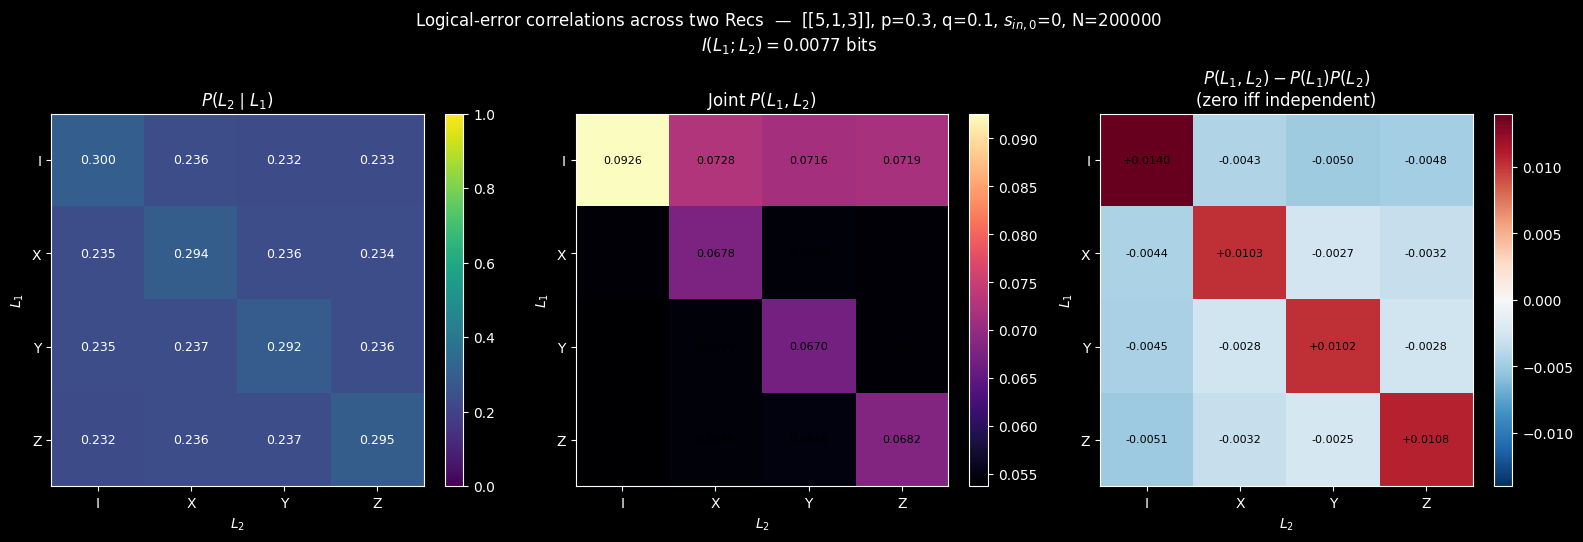

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) conditional P(L2|L1)
im0 = axes[0].imshow(P_L2_given_L1, vmin=0, vmax=1, cmap='viridis')
axes[0].set_title(r'$P(L_2 \mid L_1)$')
axes[0].set_xlabel(r'$L_2$')
axes[0].set_ylabel(r'$L_1$')
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(LOGICAL_NAMES)
axes[0].set_yticks(range(4)); axes[0].set_yticklabels(LOGICAL_NAMES)
for i in range(4):
    for j in range(4):
        v = P_L2_given_L1[i, j]
        axes[0].text(j, i, f'{v:.3f}', ha='center', va='center',
                     color='white' if v < 0.6 else 'black', fontsize=9)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# (b) joint P(L1, L2)
im1 = axes[1].imshow(P_joint_L, cmap='magma')
axes[1].set_title(r'Joint $P(L_1, L_2)$')
axes[1].set_xlabel(r'$L_2$')
axes[1].set_ylabel(r'$L_1$')
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(LOGICAL_NAMES)
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(LOGICAL_NAMES)
for i in range(4):
    for j in range(4):
        v = P_joint_L[i, j]
        axes[1].text(j, i, f'{v:.4f}', ha='center', va='center',
                     color='white' if v < P_joint_L.max() * 0.5 else 'black',
                     fontsize=8)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# (c) joint - product (Markovian-independence reference)
vmax = np.max(np.abs(diff_L))
im2 = axes[2].imshow(diff_L, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
axes[2].set_title(r'$P(L_1, L_2) - P(L_1)P(L_2)$' + '\n(zero iff independent)')
axes[2].set_xlabel(r'$L_2$')
axes[2].set_ylabel(r'$L_1$')
axes[2].set_xticks(range(4)); axes[2].set_xticklabels(LOGICAL_NAMES)
axes[2].set_yticks(range(4)); axes[2].set_yticklabels(LOGICAL_NAMES)
for i in range(4):
    for j in range(4):
        v = diff_L[i, j]
        axes[2].text(j, i, f'{v:+.4f}', ha='center', va='center',
                     color='black', fontsize=8)
plt.colorbar(im2, ax=axes[2], fraction=0.046)

fig.suptitle(f'Logical-error correlations across two Recs  —  '
             f'{code.name}, p={p_val}, q={q_val}, '
             f'$s_{{in,0}}$={s_in_0}, N={N_SAMPLES}\n'
             f'$I(L_1;L_2) = {I_LL:.4f}$ bits',
             y=1.02)
plt.tight_layout()

fname = (f'two_recs_logical_corr__{code_tag}__sin{s_in_0}__'
         f'p{p_val:g}__q{q_val:g}__N{N_SAMPLES}.png')
fpath = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print(f"Saved: {fpath}")
plt.show()

## 6. Syndrome correlations across two Recs

Same three diagnostics for the output syndromes `(s1, s2)`.

Saved: plots/two_recs_syndrome_corr__5-1-3__sin0__p0.3__q0.1__N200000.png


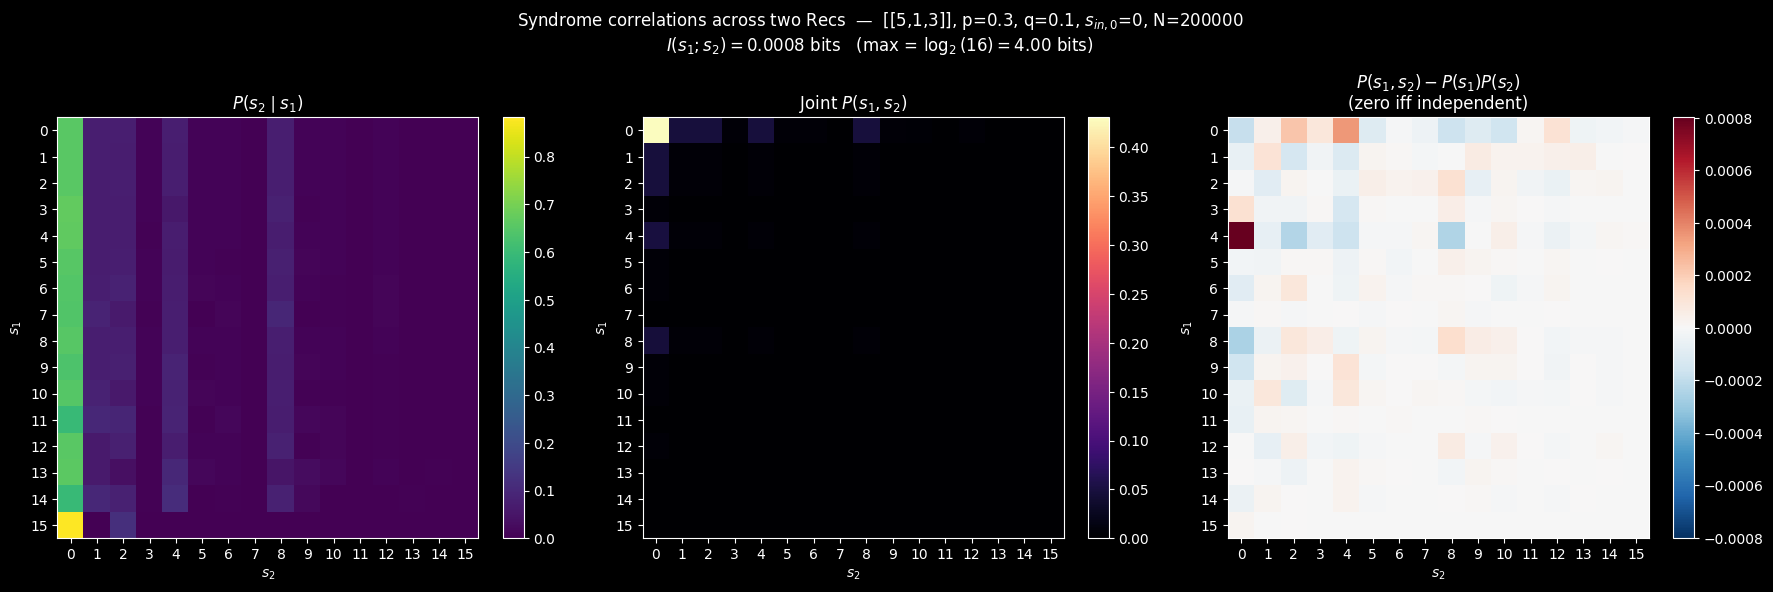

In [18]:
P_joint_s     = joint_s / joint_s.sum()
P_s1          = P_joint_s.sum(axis=1)
P_s2          = P_joint_s.sum(axis=0)
P_s2_given_s1 = conditional_from_joint(joint_s)
P_product_s   = np.outer(P_s1, P_s2)
diff_s        = P_joint_s - P_product_s
I_ss          = mutual_information_bits(joint_s)
n_syn         = code.n_syndromes

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

im0 = axes[0].imshow(P_s2_given_s1, vmin=0, vmax=P_s2_given_s1.max(), cmap='viridis')
axes[0].set_title(r'$P(s_2 \mid s_1)$')
axes[0].set_xlabel(r'$s_2$')
axes[0].set_ylabel(r'$s_1$')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(P_joint_s, cmap='magma')
axes[1].set_title(r'Joint $P(s_1, s_2)$')
axes[1].set_xlabel(r'$s_2$')
axes[1].set_ylabel(r'$s_1$')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

vmax = np.max(np.abs(diff_s))
im2 = axes[2].imshow(diff_s, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
axes[2].set_title(r'$P(s_1,s_2) - P(s_1)P(s_2)$' + '\n(zero iff independent)')
axes[2].set_xlabel(r'$s_2$')
axes[2].set_ylabel(r'$s_1$')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xticks(range(n_syn))
    ax.set_yticks(range(n_syn))

fig.suptitle(f'Syndrome correlations across two Recs  —  '
             f'{code.name}, p={p_val}, q={q_val}, '
             f'$s_{{in,0}}$={s_in_0}, N={N_SAMPLES}\n'
             f'$I(s_1;s_2) = {I_ss:.4f}$ bits   '
             f'(max = $\\log_2({n_syn}) = {np.log2(n_syn):.2f}$ bits)',
             y=1.02)
plt.tight_layout()

fname = (f'two_recs_syndrome_corr__{code_tag}__sin{s_in_0}__'
         f'p{p_val:g}__q{q_val:g}__N{N_SAMPLES}.png')
fpath = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print(f"Saved: {fpath}")
plt.show()

## 7. Sweep mutual information vs `q` (fixed `p`)

Tracks `I(L1;L2)` and `I(s1;s2)` as the syndrome bit-flip probability `q` is varied. A non-zero curve at any `q` is evidence of non-Markovian correlations between consecutive Recs.

q=0.000  I(L1;L2)=0.02335  I(s1;s2)=0.00000
q=0.100  I(L1;L2)=0.00807  I(s1;s2)=0.00164
q=0.200  I(L1;L2)=0.00295  I(s1;s2)=0.00176
q=0.300  I(L1;L2)=0.00080  I(s1;s2)=0.00198
q=0.400  I(L1;L2)=0.00040  I(s1;s2)=0.00161
q=0.500  I(L1;L2)=0.00024  I(s1;s2)=0.00171
q=0.600  I(L1;L2)=0.00024  I(s1;s2)=0.00176
q=0.700  I(L1;L2)=0.00032  I(s1;s2)=0.00158
q=0.800  I(L1;L2)=0.00078  I(s1;s2)=0.00151
q=0.900  I(L1;L2)=0.00415  I(s1;s2)=0.00148
q=1.000  I(L1;L2)=0.02339  I(s1;s2)=0.00000
Saved: plots/two_recs_MI_vs_q__5-1-3__sin0__p0.3__q0-to-1-n11__N100000.png


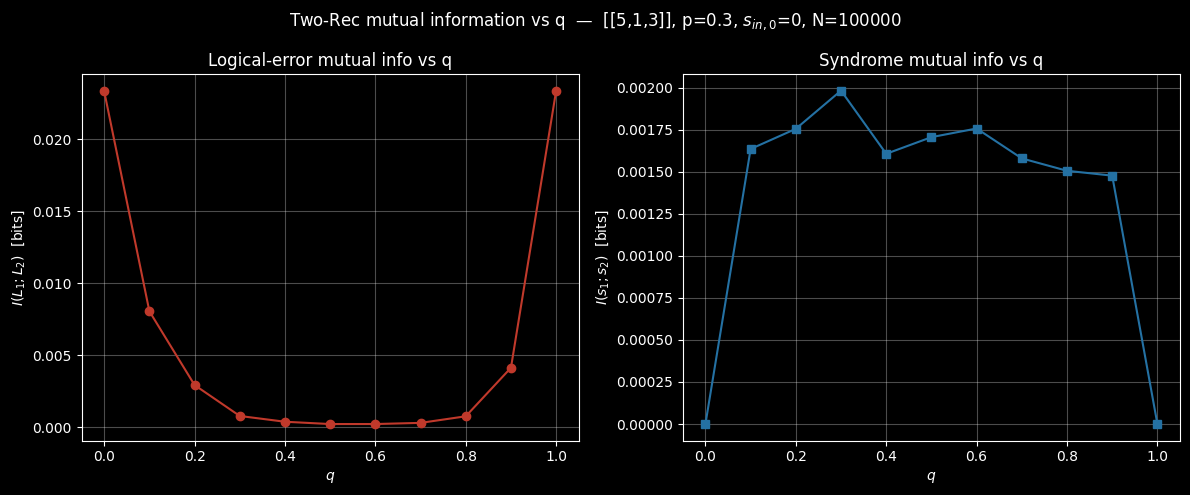

In [19]:
q_values_sweep = np.linspace(0, 1, 11)
N_SWEEP        = 100_000
p_fixed        = p_val

I_LL_q = np.zeros(len(q_values_sweep))
I_ss_q = np.zeros(len(q_values_sweep))

for iq, q in enumerate(q_values_sweep):
    jL, jS = monte_carlo_two_recs(code, s_in_0, p_fixed, q,
                                  n_samples=N_SWEEP, seed=1000 + iq)
    I_LL_q[iq] = mutual_information_bits(jL)
    I_ss_q[iq] = mutual_information_bits(jS)
    print(f"q={q:.3f}  I(L1;L2)={I_LL_q[iq]:.5f}  I(s1;s2)={I_ss_q[iq]:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(q_values_sweep, I_LL_q, 'o-', color='#c0392b')
axes[0].set_xlabel(r'$q$')
axes[0].set_ylabel(r'$I(L_1 ; L_2)$  [bits]')
axes[0].set_title('Logical-error mutual info vs q')
axes[0].grid(alpha=0.3)

axes[1].plot(q_values_sweep, I_ss_q, 's-', color='#2471a3')
axes[1].set_xlabel(r'$q$')
axes[1].set_ylabel(r'$I(s_1 ; s_2)$  [bits]')
axes[1].set_title('Syndrome mutual info vs q')
axes[1].grid(alpha=0.3)

fig.suptitle(f'Two-Rec mutual information vs q  —  '
             f'{code.name}, p={p_fixed}, $s_{{in,0}}$={s_in_0}, N={N_SWEEP}')
plt.tight_layout()

q_tag = f"q{q_values_sweep[0]:g}-to-{q_values_sweep[-1]:g}-n{len(q_values_sweep)}"
fname = (f'two_recs_MI_vs_q__{code_tag}__sin{s_in_0}__'
         f'p{p_fixed:g}__{q_tag}__N{N_SWEEP}.png')
fpath = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print(f"Saved: {fpath}")
plt.show()

## 8. Sweep mutual information vs `p` (fixed `q`)

p=0.000  I(L1;L2)=0.00000  I(s1;s2)=0.00175
p=0.050  I(L1;L2)=0.23897  I(s1;s2)=0.00153
p=0.100  I(L1;L2)=0.22718  I(s1;s2)=0.00108
p=0.150  I(L1;L2)=0.13544  I(s1;s2)=0.00128
p=0.200  I(L1;L2)=0.06135  I(s1;s2)=0.00150
p=0.250  I(L1;L2)=0.02356  I(s1;s2)=0.00153
p=0.300  I(L1;L2)=0.00714  I(s1;s2)=0.00143
p=0.350  I(L1;L2)=0.00237  I(s1;s2)=0.00149
p=0.400  I(L1;L2)=0.00056  I(s1;s2)=0.00146
p=0.450  I(L1;L2)=0.00007  I(s1;s2)=0.00196
p=0.500  I(L1;L2)=0.00008  I(s1;s2)=0.00167
Saved: plots/two_recs_MI_vs_p__5-1-3__sin0__q0.1__p0-to-0.5-n11__N100000.png


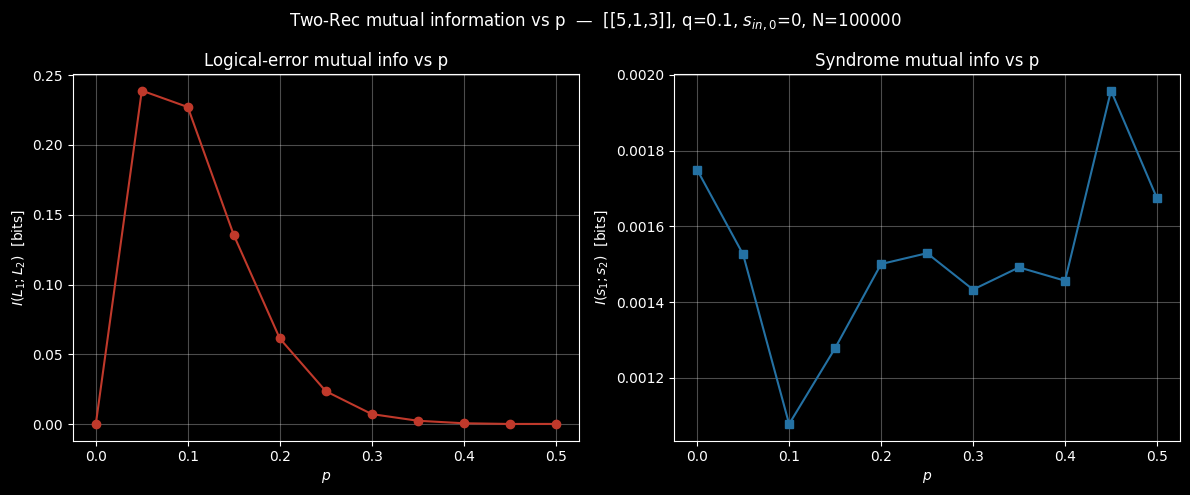

In [20]:
p_values_sweep = np.linspace(0, 0.5, 11)
N_SWEEP_P      = 100_000
q_fixed        = q_val

I_LL_p = np.zeros(len(p_values_sweep))
I_ss_p = np.zeros(len(p_values_sweep))

for ip, p in enumerate(p_values_sweep):
    jL, jS = monte_carlo_two_recs(code, s_in_0, p, q_fixed,
                                  n_samples=N_SWEEP_P, seed=2000 + ip)
    I_LL_p[ip] = mutual_information_bits(jL)
    I_ss_p[ip] = mutual_information_bits(jS)
    print(f"p={p:.3f}  I(L1;L2)={I_LL_p[ip]:.5f}  I(s1;s2)={I_ss_p[ip]:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(p_values_sweep, I_LL_p, 'o-', color='#c0392b')
axes[0].set_xlabel(r'$p$')
axes[0].set_ylabel(r'$I(L_1 ; L_2)$  [bits]')
axes[0].set_title('Logical-error mutual info vs p')
axes[0].grid(alpha=0.3)

axes[1].plot(p_values_sweep, I_ss_p, 's-', color='#2471a3')
axes[1].set_xlabel(r'$p$')
axes[1].set_ylabel(r'$I(s_1 ; s_2)$  [bits]')
axes[1].set_title('Syndrome mutual info vs p')
axes[1].grid(alpha=0.3)

fig.suptitle(f'Two-Rec mutual information vs p  —  '
             f'{code.name}, q={q_fixed}, $s_{{in,0}}$={s_in_0}, N={N_SWEEP_P}')
plt.tight_layout()

p_tag = f"p{p_values_sweep[0]:g}-to-{p_values_sweep[-1]:g}-n{len(p_values_sweep)}"
fname = (f'two_recs_MI_vs_p__{code_tag}__sin{s_in_0}__'
         f'q{q_fixed:g}__{p_tag}__N{N_SWEEP_P}.png')
fpath = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print(f"Saved: {fpath}")
plt.show()